# Análise Exploratória de Dados — Desenvolvimento Humano Global com Gapminder

Autor: Rodrigo Emygdio da Silva Simas Pereira

PUC Minas — Pós-graduação em Inteligência Artificial e Aprendizado de Máquina

Disciplina: Python para Ciência de Dados

# Introdução
Este trabalho realiza uma Análise Exploratória de Dados (EDA) utilizando o dataset Gapminder, com o objetivo de investigar padrões globais de desenvolvimento humano entre 1952 e 2007.

A análise busca compreender como fatores econômicos, geográficos e demográficos se relacionam com a expectativa de vida das populações ao redor do mundo.

## Perguntas Investigadas

- Como a expectativa de vida evoluiu entre 1952 e 2007?
- Existem desigualdades persistentes entre continentes?
- PIB per capita possui relação com expectativa de vida?
- Existem países ricos com expectativa de vida relativamente baixa?
- A Ásia apresenta heterogeneidade interna significativa?
- Oceania realmente possui vantagem estrutural sobre Europa?

## Metodologia da Análise

A análise foi organizada como uma EDA estruturada, seguindo as etapas abaixo:

1. inspeção inicial da estrutura do dataset;
2. validação de duplicados e dados ausentes;
3. verificação da cobertura temporal e geográfica;
4. análise da evolução histórica da expectativa de vida;
5. comparação entre continentes e países;
6. investigação da relação entre PIB per capita, população e expectativa de vida;
7. identificação de exceções e limitações metodológicas.

As visualizações foram escolhidas de acordo com o tipo de pergunta investigada. Gráficos de linha foram utilizados para evolução temporal, gráficos de barras para rankings e contagens, boxplots para comparação de distribuições, scatter plots para relações entre variáveis numéricas e heatmaps para correlações.


## Mapa das Análises Entregues

Este notebook contempla mais de 15 análises exploratórias, entre elas:

1. estrutura inicial do dataset;
2. estatísticas descritivas das variáveis numéricas;
3. validação de duplicados exatos e por chave lógica;
4. mapa de duplicados por país e ano;
5. validação de dados ausentes;
6. cobertura temporal do dataset;
7. quantidade de países por ano;
8. evolução global da expectativa de vida;
9. comparação entre média simples e média ponderada pela população;
10. evolução da expectativa de vida por continente;
11. distribuição da expectativa de vida por continente;
12. comparação entre Oceania e Europa;
13. Top 10 países em expectativa de vida;
14. persistência dos países no Top 10;
15. disparidade global da expectativa de vida ao longo do tempo;
16. heterogeneidade da Ásia em 2007;
17. trajetórias asiáticas selecionadas;
18. relação entre PIB per capita e expectativa de vida;
19. correlação entre variáveis numéricas;
20. países com PIB alto e expectativa abaixo do esperado;
21. população, PIB per capita e expectativa de vida.


## Import Libs

In [1]:
import os
from enum import Enum
from typing import NamedTuple

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from IPython.core.magics import display



## Módulo de Funções

In [2]:

class Scale(Enum):
    LOG = "log"
    LINEAR = "linear"


class ColumnPos(Enum):
    X = 0
    Y = 1


class Posicao(Enum):
    INICIAL = 0
    FINAL = 1


class Coluna(NamedTuple):
    nome_coluna: str
    label: str
    sortable: bool


class ColumnScale:
    def __init__(self, coluna: ColumnPos, scale: Scale):
        self.scale = scale
        self.coluna = coluna


def filtrar_ano(data_frame, ano):
    return data_frame[data_frame["year"] == ano].copy()


def top_n(data_frame, coluna, n=10, ascending=False, colunas=None):
    resultado = data_frame.sort_values(coluna, ascending=ascending).head(n)
    if colunas is not None:
        resultado = resultado[colunas]
    return resultado


def aplicar_formatacao_grafico(titulo, xlabel, ylabel, grid=True, legend=False):
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if legend:
        plt.legend()
    if grid:
        plt.grid(True, alpha=0.3)
    plt.show()


def grafico_linha(
        data_frame,
        coluna_x,
        coluna_y,
        titulo,
        xlabel,
        ylabel,
        label=None,
        marker="o",
        figsize=None,
):
    if figsize is not None:
        plt.figure(figsize=figsize)
    plt.plot(
        data_frame[coluna_x],
        data_frame[coluna_y],
        marker=marker,
        label=label,
    )
    aplicar_formatacao_grafico(
        titulo=titulo,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=label is not None,
    )


def grafico_linhas_por_grupo(
        data_frame,
        grupo,
        coluna_x,
        coluna_y,
        titulo,
        xlabel,
        ylabel,
        marker="o",
        figsize=None,
):
    if figsize is not None:
        plt.figure(figsize=figsize)
    for nome_grupo, dados in data_frame.groupby(grupo):
        plt.plot(
            dados[coluna_x],
            dados[coluna_y],
            marker=marker,
            label=nome_grupo,
        )
    aplicar_formatacao_grafico(
        titulo=titulo,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=True,
    )


def grafico_scatter(
        data_frame,
        coluna_x,
        coluna_y,
        titulo,
        xlabel,
        ylabel,
        scale_x=None,
        tamanho=None,
        alpha=0.5,
        label=None,
        figsize=None,
):
    if figsize is not None:
        plt.figure(figsize=figsize)
    plt.scatter(
        data_frame[coluna_x],
        data_frame[coluna_y],
        s=tamanho,
        alpha=alpha,
        label=label,
    )
    if scale_x is not None:
        plt.xscale(scale_x)
    aplicar_formatacao_grafico(
        titulo=titulo,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=label is not None,
    )


def anotar_paises(data_frame, coluna_x, coluna_y, coluna_texto="country", fontsize=8):
    for _, row in data_frame.iterrows():
        plt.text(
            row[coluna_x],
            row[coluna_y],
            row[coluna_texto],
            fontsize=fontsize,
        )


def plotar_boxplot_por_grupo(
        data_frame,
        coluna_valor,
        coluna_grupo,
        titulo,
        xlabel,
        ylabel,
        figsize=(10, 5),
):
    """Compara a distribuição de uma variável numérica entre grupos categóricos."""
    data_frame.boxplot(
        column=coluna_valor,
        by=coluna_grupo,
        figsize=figsize,
    )
    plt.title(titulo)
    plt.suptitle("")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


def grafico_barra(
        colunas: tuple[Coluna],
        data_frame,
        quantidade: int=0,
        scale: ColumnScale=None,
        title="",
):
    coluna_x, coluna_y = colunas
    sortable_by = None

    for coluna in colunas:
        if coluna.sortable:
            sortable_by = coluna.nome_coluna
            break
    if quantidade != 0 and sortable_by is not None:
        data_frame = top_n(data_frame, sortable_by, n=quantidade, ascending=True)

    data_frame.plot(
        kind="bar",
        x=coluna_x.nome_coluna,
        y=coluna_y.nome_coluna,
        legend=False,
        figsize=(10, 5),
    )
    if scale is not None:
        if scale.coluna == ColumnPos.X:
            plt.xscale(scale.scale.value)
        elif scale.coluna == ColumnPos.Y:
            plt.yscale(scale.scale.value)

    plt.title(title)
    plt.xlabel(coluna_x.label)
    plt.ylabel(coluna_y.label)
    plt.xticks(rotation=45, ha="right")
    plt.show()


def graf_evolu_pais(paises_por_ano, paises=None):
    if paises is None:
        paises = ["Brazil", "Portugal", "China"]

    plt.figure(figsize=(10, 5))
    for pais, group in paises_por_ano:
        if pais in paises:
            plt.plot(
                group["year"],
                group["lifeExp"],
                marker="o",
                label=pais,
            )
    plt.legend()
    plt.show()


def plotar_barras_horizontais(
        data_frame,
        coluna_categoria,
        coluna_valor,
        titulo,
        xlabel,
        ylabel,
        figsize=(10, 5),
        inverter_ordem=True,
):
    """Desenha um gráfico de barras horizontais para um DataFrame já preparado."""
    plt.figure(figsize=figsize)
    plt.barh(data_frame[coluna_categoria], data_frame[coluna_valor])
    if inverter_ordem:
        plt.gca().invert_yaxis()
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()


def plotar_ranking_por_ano(
        ano,
        data_frame,
        colunas: tuple[Coluna, Coluna],
        titulo,
        posicao=Posicao.INICIAL,
        quantidade=10,
):
    """Filtra o ano, monta um ranking e o exibe em barras horizontais."""
    coluna_categoria, coluna_valor = colunas
    coluna_ordenacao = None

    df_ano = filtrar_ano(data_frame, ano)
    for coluna in colunas:
        if coluna.sortable:
            coluna_ordenacao = coluna.nome_coluna
            break

    if coluna_ordenacao is not None:
        df_ano = df_ano.sort_values(coluna_ordenacao, ascending=False)

    if posicao == Posicao.INICIAL:
        ranking = df_ano.head(quantidade)
    elif posicao == Posicao.FINAL:
        ranking = df_ano.tail(quantidade)
    else:
        ranking = df_ano

    plotar_barras_horizontais(
        data_frame=ranking,
        coluna_categoria=coluna_categoria.nome_coluna,
        coluna_valor=coluna_valor.nome_coluna,
        titulo=titulo,
        xlabel=coluna_valor.label,
        ylabel=coluna_categoria.label,
        figsize=(12, 20),
        inverter_ordem=False,
    )


## Estrutura dos Dados

In [3]:
DATA_SET_PATH = '../datasets'
df = pd.read_csv(os.path.join(DATA_SET_PATH, 'gapminder_full.csv'))

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1736 non-null   str    
 1   year       1736 non-null   int64  
 2   pop        1736 non-null   float64
 3   continent  1736 non-null   str    
 4   lifeExp    1736 non-null   float64
 5   gdpPercap  1736 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 81.5 KB


In [5]:
df.describe()

,year,pop,lifeExp,gdpPercap
count,1736.000000,1.736000e+03,1736.000000,1736.000000
mean,1979.669931,3.156800e+07,59.511979,7240.155986
std,17.296364,1.172888e+08,12.956028,9839.873695
min,1952.000000,6.001100e+04,23.599000,241.165876
25%,1967.000000,2.818694e+06,48.245000,1202.060309
50%,1982.000000,7.150606e+06,60.808000,3534.772106
75%,1997.000000,1.977102e+07,70.945000,9380.254270
max,2007.000000,1.318683e+09,82.603000,113523.132900


In [6]:
df.head(10)

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
5,Afghanistan,1977,14880372.0,Asia,38.438,786.113360
6,Afghanistan,1982,12881816.0,Asia,39.854,978.011439
7,Afghanistan,1987,13867957.0,Asia,40.822,852.395945
8,Afghanistan,1992,16317921.0,Asia,41.674,649.341395
9,Afghanistan,1997,22227415.0,Asia,41.763,635.341351


## Limpeza e Tratamento

### Verificação de Duplicados

In [7]:
df.duplicated().sum()

np.int64(32)

In [8]:
df.duplicated(subset=['country', 'year']).sum()

np.int64(32)

In [9]:
filter_dups_first = df.duplicated(subset=["country", 'year'], keep='first')
dups_chave = df[df.duplicated(subset=['country', 'year'], keep=False)].sort_values(by=['country', 'year'])
dups_por_pais = (
    df[filter_dups_first].groupby(['country'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='qtd_linhas_duplicadas')
)
dups_por_pais

,country,qtd_linhas_duplicadas
0,France,7
1,Guinea,5
2,Bolivia,5
3,Ecuador,3
4,Equatorial Guinea,3
5,China,3
6,Czech Republic,2
7,Belgium,1
8,Afghanistan,1
9,Burkina Faso,1


In [10]:
matriz_dups = (
    dups_chave.groupby(['country', 'year'])
    .size()
    .unstack(fill_value=0)
)


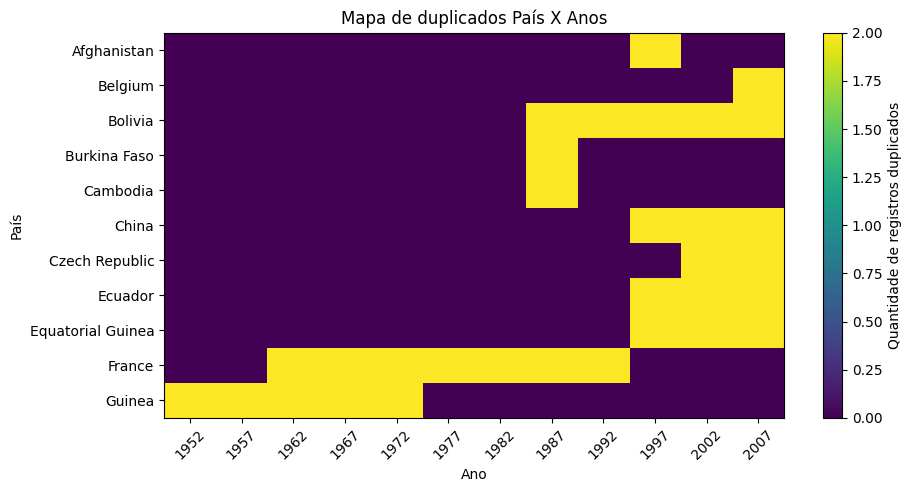

In [11]:
plt.figure(figsize=(10,5))
plt.imshow(matriz_dups, aspect='auto')
plt.title("Mapa de duplicados País X Anos")

plt.xlabel('Ano')
plt.ylabel('País')

plt.xticks(
    ticks=range(len(matriz_dups.columns)),
    labels=matriz_dups.columns,
    rotation=45,
)
plt.yticks(
    ticks=range(len(matriz_dups.index)),
    labels=matriz_dups.index,
)
plt.colorbar(label='Quantidade de registros duplicados')
plt.show()

In [12]:
df = df.drop_duplicates()

In [13]:
df.groupby(['country', 'year']).nunique().max()

pop          1
continent    1
lifeExp      1
gdpPercap    1
dtype: int64

### Verificação de Dados Ausentes


In [14]:
df.isna().sum()

country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64

Estrutura Temporal e Cobertura

## Estrutura Temporal e Cobertura

### Cobertura dos Anos

In [15]:
anos = df["year"].unique()
print("Quantidade de Anos: ",anos.shape[0])
anos

Quantidade de Anos:  12


array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

### Quantidade de Países

In [16]:
df["country"].unique().shape

(142,)

### Periodicidade

In [17]:
pd.Series(sorted(anos)).diff().value_counts()

5.0    11
Name: count, dtype: int64

### Países por Ano

In [18]:
paises_por_ano = df.groupby('year')['country'].nunique().reset_index(name='qtd_paises')
paises_por_ano.head()

,year,qtd_paises
0,1952,142
1,1957,142
2,1962,142
3,1967,142
4,1972,142


In [19]:
paises_por_ano.describe()

,year,qtd_paises
count,12.000000,12.0
mean,1979.500000,142.0
std,18.027756,0.0
min,1952.000000,142.0
25%,1965.750000,142.0
50%,1979.500000,142.0
75%,1993.250000,142.0
max,2007.000000,142.0


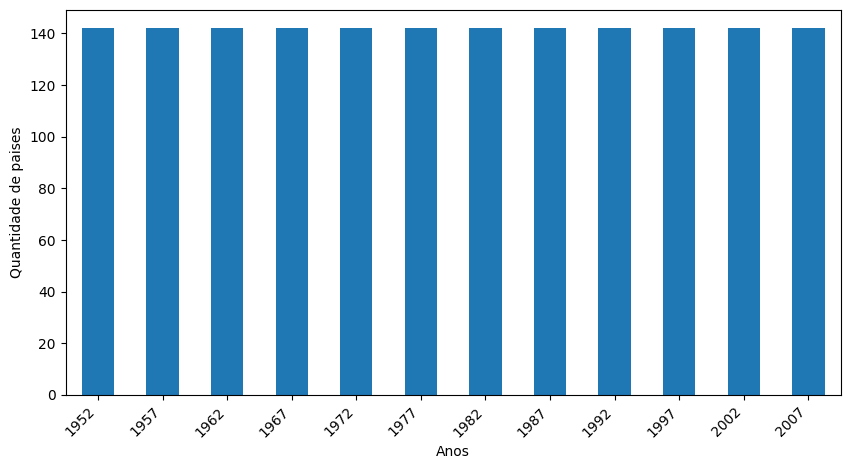

In [20]:
grafico_barra(
    (Coluna(nome_coluna="year",label="Anos",sortable=True),Coluna(nome_coluna="qtd_paises",label="Quantidade de paises",sortable=False)),
    data_frame=paises_por_ano

)

**_Estrutura Temporal do Dataset_**

Antes das análises exploratórias, foi realizada uma investigação da estrutura temporal do dataset para compreender a periodicidade das observações e verificar a consistência da cobertura entre os países.

A análise dos anos disponíveis mostrou que os dados são coletados em intervalos regulares de 5 anos, caracterizando uma periodicidade quinquenal.

Também foi avaliado se todos os países possuíam a mesma quantidade de observações ao longo do tempo. Essa verificação é importante para identificar possíveis séries temporais incompletas e garantir comparações consistentes entre países e continentes.

Os resultados indicam que o dataset possui estrutura temporal balanceada, com os países apresentando observações para os mesmos períodos históricos.

## Evolução Global da Expectativa de Vida

### Evolução global

In [21]:
life_global = df.groupby('year')['lifeExp'].mean().reset_index()
life_global.head()

,year,lifeExp
0,1952,49.057620
1,1957,51.507401
2,1962,53.609249
3,1967,55.678290
4,1972,57.647386


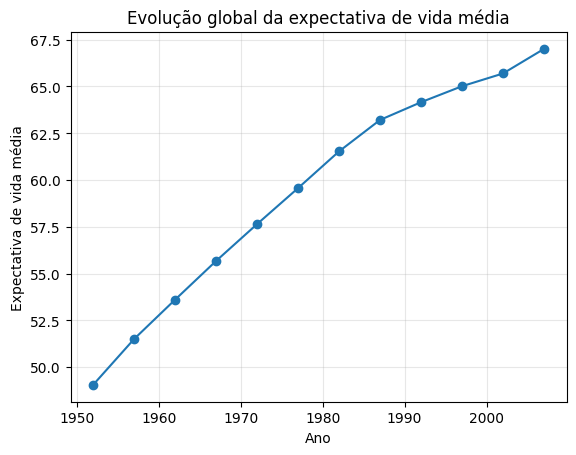

In [22]:
grafico_linha(
    data_frame=life_global,
    coluna_x="year",
    coluna_y="lifeExp",
    titulo="Evolução global da expectativa de vida média",
    xlabel="Ano",
    ylabel="Expectativa de vida média",
)


#### Média simples vs média ponderada pela população

A média global simples trata todos os países com o mesmo peso. No entanto, países com populações muito diferentes, como China, Índia e Islândia, representam quantidades muito distintas de pessoas.

Por isso, foi calculada também uma média ponderada pela população, permitindo comparar duas perspectivas:

- **média simples por país**: cada país tem o mesmo peso;
- **média ponderada pela população**: países mais populosos têm maior peso no indicador global.


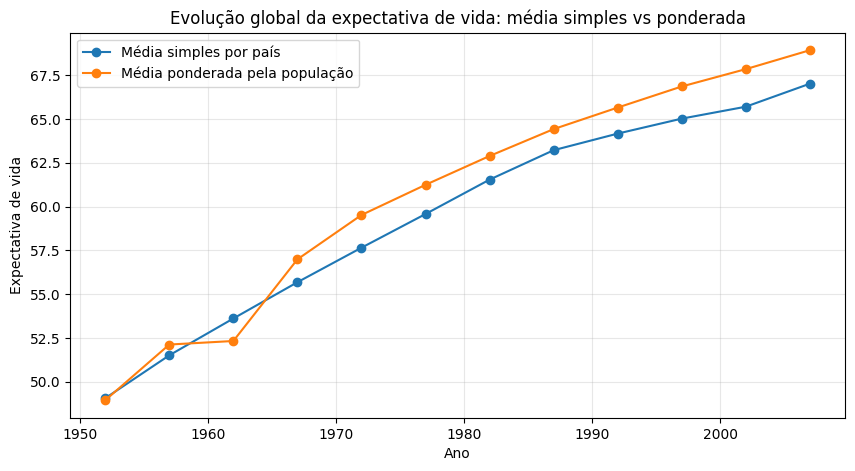

,year,lifeExp_media_simples,lifeExp_ponderada_populacao
0,1952,49.057620,48.944237
1,1957,51.507401,52.121885
2,1962,53.609249,52.324382
3,1967,55.678290,56.984307
4,1972,57.647386,59.514783
5,1977,59.570157,61.237256
6,1982,61.533197,62.881755
7,1987,63.212613,64.416350
8,1992,64.160338,65.645900
9,1997,65.014676,66.849343


In [23]:
life_global_mean = (
    df.groupby("year")["lifeExp"]
    .mean()
    .reset_index(name="lifeExp_media_simples")
)

life_global_weighted = (
    df.groupby("year")
    .apply(lambda x: (x["lifeExp"] * x["pop"]).sum() / x["pop"].sum())
    .reset_index(name="lifeExp_ponderada_populacao")
)

life_global_compare = life_global_mean.merge(
    life_global_weighted,
    on="year",
)

plt.figure(figsize=(10, 5))

plt.plot(
    life_global_compare["year"],
    life_global_compare["lifeExp_media_simples"],
    marker="o",
    label="Média simples por país",
)

plt.plot(
    life_global_compare["year"],
    life_global_compare["lifeExp_ponderada_populacao"],
    marker="o",
    label="Média ponderada pela população",
)

aplicar_formatacao_grafico(
    titulo="Evolução global da expectativa de vida: média simples vs ponderada",
    xlabel="Ano",
    ylabel="Expectativa de vida",
    legend=True,
)

life_global_compare


A comparação entre média simples e média ponderada pela população revela uma diferença metodológica importante. A média simples considera cada país com o mesmo peso, enquanto a média ponderada atribui maior influência aos países mais populosos.

Observa-se que, nos primeiros anos da série, especialmente em 1952 e meados da década de 1960, a média ponderada era inferior à média simples. Isso sugere que países com grande população apresentavam expectativa de vida relativamente menor nesse período, puxando a média populacional para baixo.

Ao longo do tempo, a aproximação e posterior elevação da média ponderada indicam melhora significativa em países populosos, contribuindo de forma expressiva para o aumento da expectativa de vida global.

In [52]:
df_ano_62 = df[df["year"] == 1962].copy()
media_simples = df_ano_62["lifeExp"].mean()
top_ano = df_ano_62.sort_values("pop", ascending=False).head(10)[["country", "continent", "pop", "lifeExp", "gdpPercap"]]
top_ano["media_simples_ano"] = media_simples
top_ano["dif_lifeExp_media"] = top_ano["lifeExp"] - top_ano["media_simples_ano"]
top_ano

,country,continent,pop,lifeExp,gdpPercap,media_simples_ano,dif_lifeExp_media
299,China,Asia,665770000.0,44.50136,487.674018,53.609249,-9.107889
730,India,Asia,454000000.0,43.60500,658.347151,53.609249,-10.004249
1642,United States,Americas,186538000.0,70.21000,16173.145860,53.609249,16.600751
742,Indonesia,Asia,99028000.0,42.51800,849.289770,53.609249,-11.091249
826,Japan,Asia,95831757.0,68.73000,6576.649461,53.609249,15.120751
177,Brazil,Americas,76039390.0,55.66500,3336.585802,53.609249,2.055751
593,Germany,Europe,73739117.0,70.30000,12902.462910,53.609249,16.690751
99,Bangladesh,Asia,56839289.0,41.21600,686.341554,53.609249,-12.393249
1630,United Kingdom,Europe,53292000.0,70.76000,12477.177070,53.609249,17.150751
1198,Pakistan,Asia,53100671.0,47.67000,803.342742,53.609249,-5.939249


#### Evolução por continente

In [24]:
expect_vida_continente = df.groupby(["continent","year"])["lifeExp"].mean().reset_index()
expect_vida_continente.sort_values(by="lifeExp", ascending=False).head(10)

,continent,year,lifeExp
59,Oceania,2007,80.719500
58,Oceania,2002,79.740000
57,Oceania,1997,78.190000
47,Europe,2007,77.648600
56,Oceania,1992,76.945000
46,Europe,2002,76.700600
45,Europe,1997,75.505167
55,Oceania,1987,75.320000
44,Europe,1992,74.440100
54,Oceania,1982,74.290000


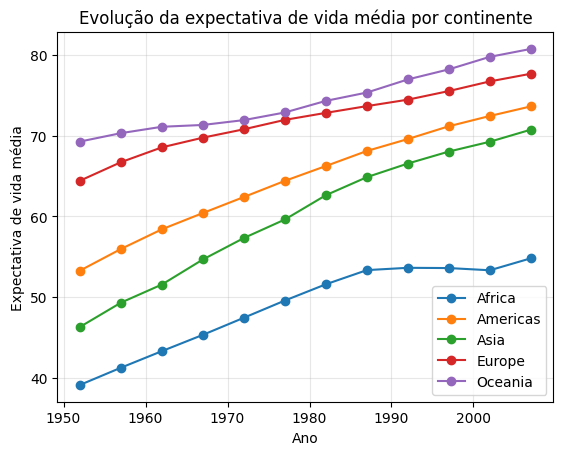

In [25]:
grafico_linhas_por_grupo(
    data_frame=expect_vida_continente,
    grupo="continent",
    coluna_x="year",
    coluna_y="lifeExp",
    titulo="Evolução da expectativa de vida média por continente",
    xlabel="Ano",
    ylabel="Expectativa de vida média",
)


### Dispersão por continente

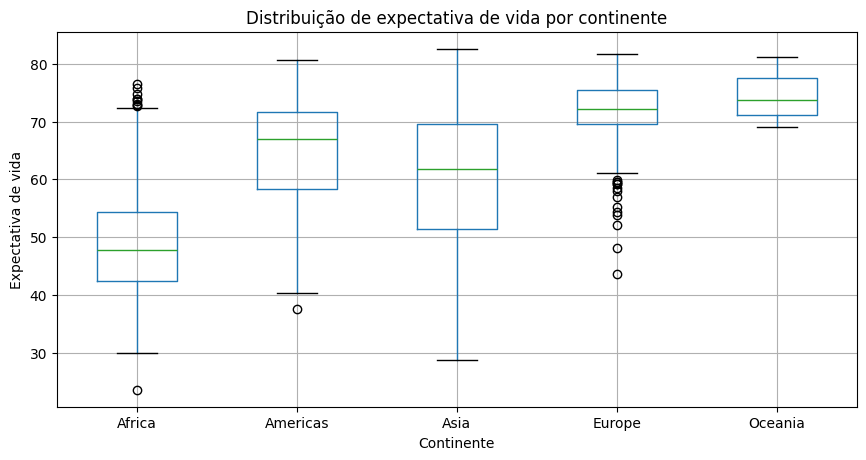

In [26]:
plotar_boxplot_por_grupo(
    data_frame=df,
    coluna_valor="lifeExp",
    coluna_grupo="continent",
    titulo="Distribuição de expectativa de vida por continente",
    xlabel="Continente",
    ylabel="Expectativa de vida",
)


**_Evolução da expectativa de vida por continente_**

A análise da evolução da expectativa de vida por continente mostra que houve aumento generalizado da qualidade de vida ao longo do período analisado. No entanto, esse crescimento não ocorreu de forma uniforme entre os continentes.

Europa e Oceania mantiveram-se consistentemente entre os maiores níveis de expectativa de vida durante toda a série histórica. As Américas apresentaram comportamento intermediário, com crescimento gradual e posição relativamente estável em relação aos demais continentes.

A Ásia apresentou forte crescimento ao longo do período, impulsionada principalmente pela melhora em países populosos e por economias que passaram por intenso desenvolvimento social e econômico. Apesar dessa evolução, a média asiática permaneceu abaixo da média das Américas em boa parte da série, indicando grande heterogeneidade interna no continente.

A África, por sua vez, apresentou os menores níveis de expectativa de vida em praticamente todo o período analisado. Embora tenha havido melhora ao longo dos anos, o crescimento foi mais limitado em comparação com os demais continentes, mantendo o continente na posição de menor expectativa de vida média no dataset.

In [27]:
df_2007 = filtrar_ano(df, 2007)

comparacao_continentes_2007 = (
    df_2007
    .groupby("continent")["lifeExp"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

comparacao_continentes_2007


,count,mean,median,std,min,max
continent,,,,,,
Oceania,2,80.719500,80.7195,0.729027,80.204,81.235
Europe,30,77.648600,78.6085,2.979813,71.777,81.757
Americas,25,73.608120,72.8990,4.440948,60.916,80.653
Asia,33,70.728485,72.3960,7.963724,43.828,82.603
Africa,52,54.806038,52.9265,9.630781,39.613,76.442


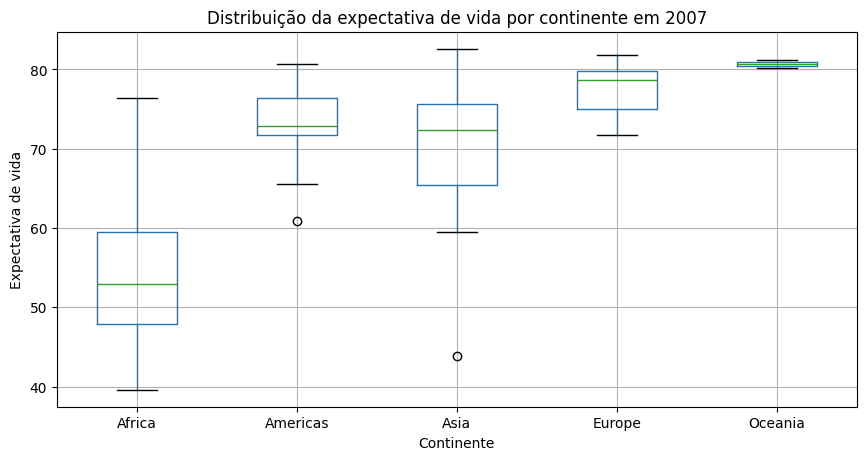

In [28]:
plotar_boxplot_por_grupo(
    data_frame=df_2007,
    coluna_valor="lifeExp",
    coluna_grupo="continent",
    titulo="Distribuição da expectativa de vida por continente em 2007",
    xlabel="Continente",
    ylabel="Expectativa de vida",
)


**_Comparação entre Oceania e Europa em 2007_**

A Oceania apresenta médias elevadas de expectativa de vida, mas possui poucos países no dataset. Portanto, a comparação com a Europa precisa considerar não apenas a média, mas também a quantidade de países e a dispersão interna.


## Desigualdade Global

### Top 10 países

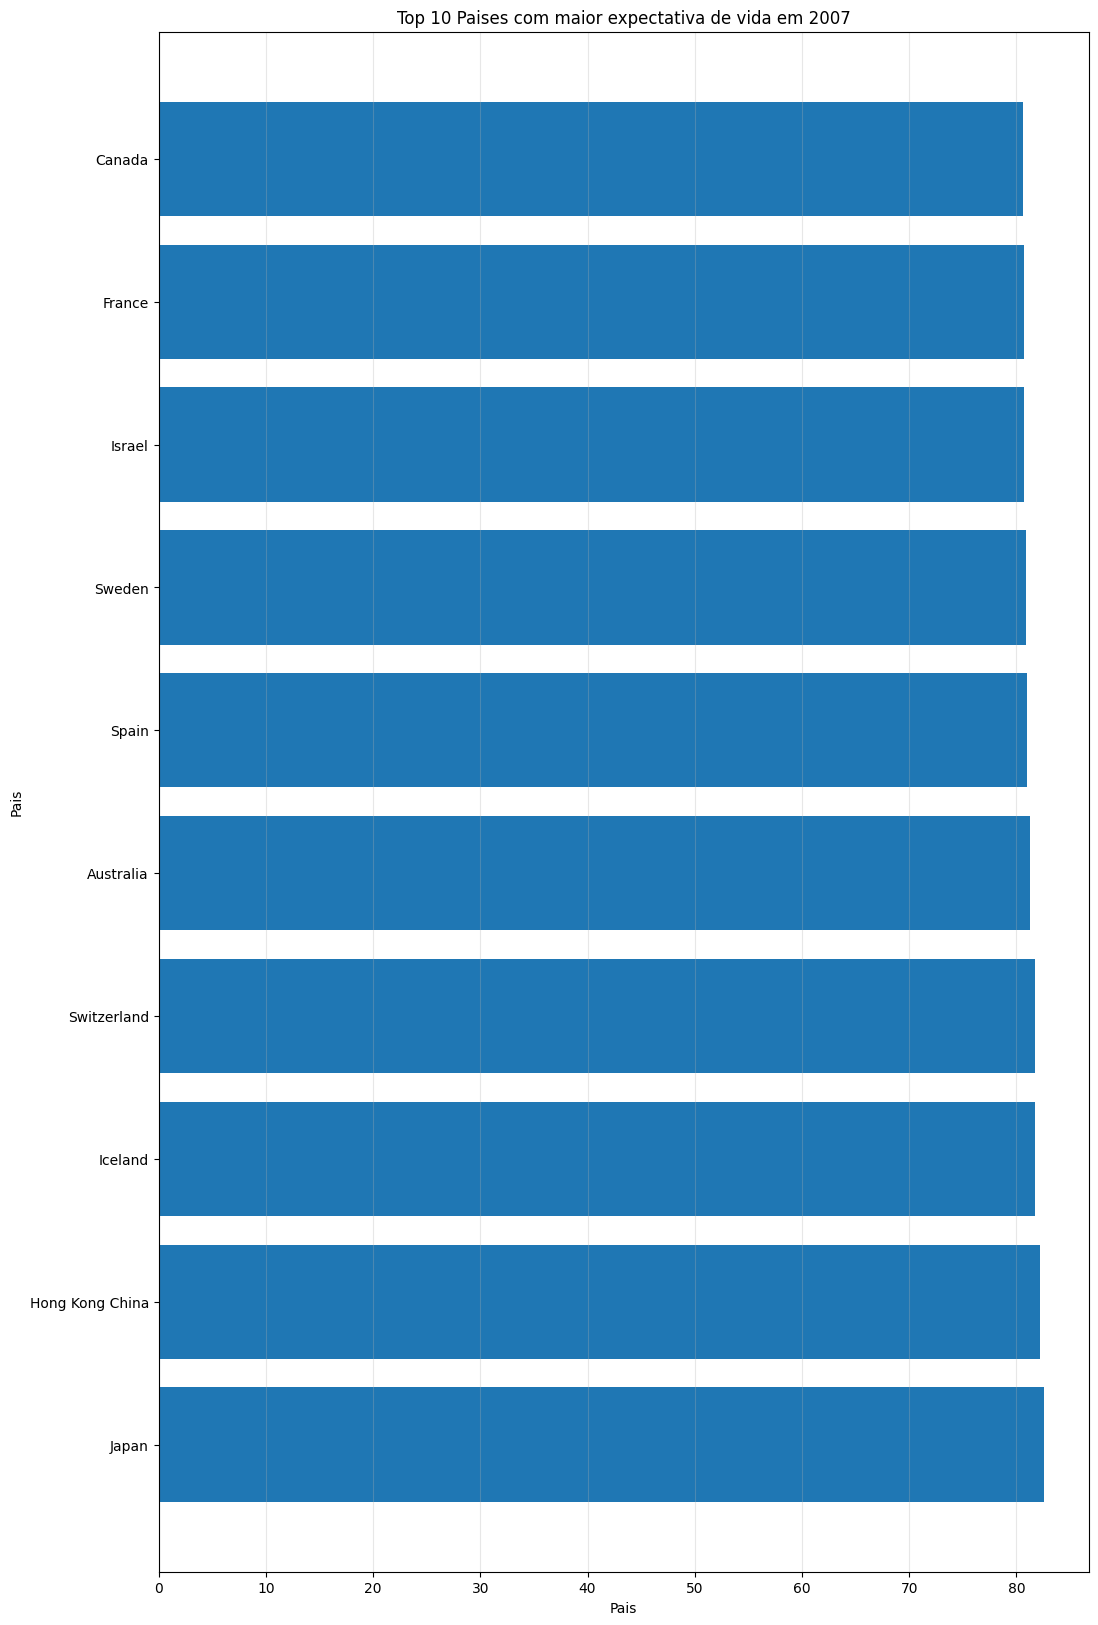

In [29]:
colunas = (Coluna(nome_coluna="country", label="Pais", sortable=False),
           Coluna(nome_coluna="lifeExp", label="Pais", sortable=True))

ano_mais_recente = df['year'].max()
plotar_ranking_por_ano(
    ano=ano_mais_recente,
    data_frame=df,
    colunas=colunas,
    titulo=f"Top 10 Paises com maior expectativa de vida em {ano_mais_recente}",
    quantidade=10,
)

### Persistência no Top 10

In [30]:
top10_por_ano = df.sort_values(['year', 'lifeExp'], ascending=[True, False]).groupby('year').head(10)

frequencia_top10 = top10_por_ano["country"].value_counts().reset_index()
frequencia_top10.columns = ["country","frequencia_top10"]
frequencia_top10.head(10)

,country,frequencia_top10
0,Iceland,12
1,Sweden,12
2,Switzerland,12
3,Canada,12
4,Spain,9
5,Netherlands,8
6,Japan,8
7,Norway,7
8,Australia,7
9,France,7


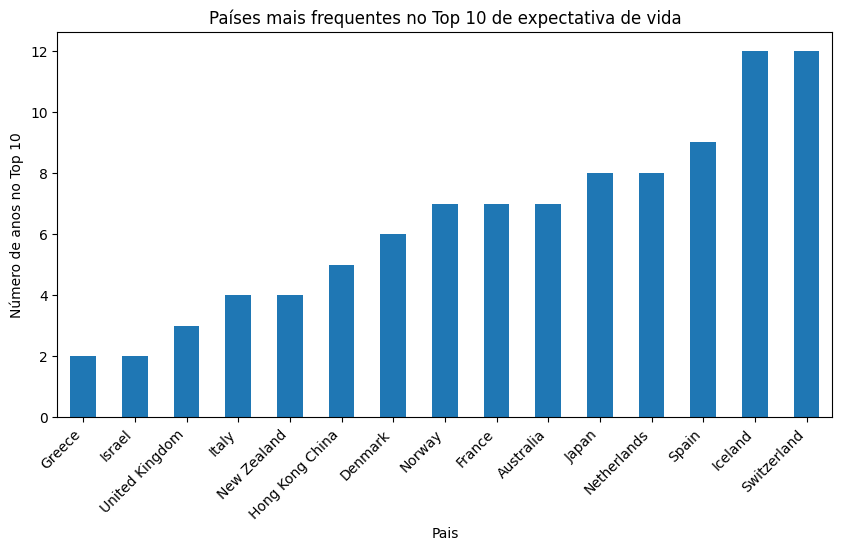

In [31]:
grafico_barra(
    (Coluna(nome_coluna="country",label="Pais",sortable=False),Coluna(nome_coluna="frequencia_top10",label="Número de anos no Top 10",sortable=True)),
    quantidade=15,
    data_frame=frequencia_top10,
     title="Países mais frequentes no Top 10 de expectativa de vida", scale=None
)

### Países com maior crescimento da expectativa de vida

Além de observar os países líderes em expectativa de vida, é importante identificar quais países apresentaram maior evolução entre o primeiro e o último ano do dataset. Essa análise evidencia trajetórias de melhoria acelerada em desenvolvimento humano.


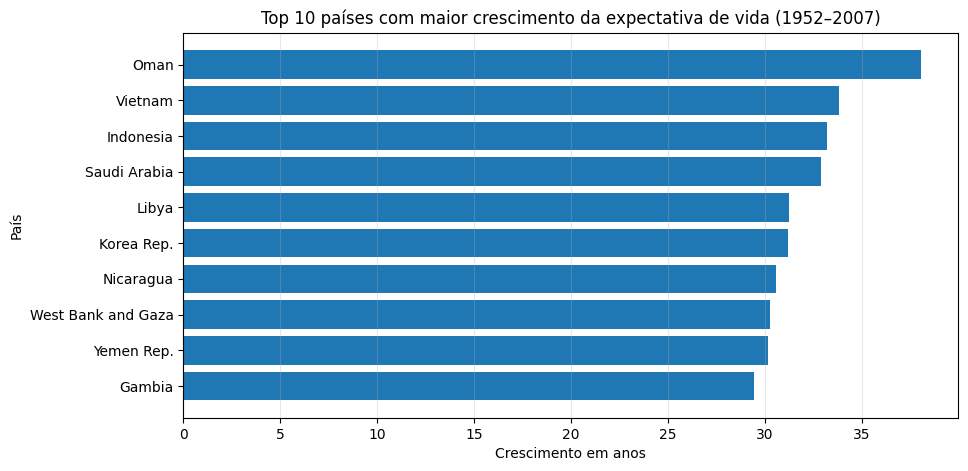

year,country,crescimento_1952_2007
0,Oman,38.062
1,Vietnam,33.837
2,Indonesia,33.182
3,Saudi Arabia,32.902
4,Libya,31.229
5,Korea Rep.,31.170
6,Nicaragua,30.585
7,West Bank and Gaza,30.262
8,Yemen Rep.,30.150
9,Gambia,29.448


In [32]:
life_growth = (
    df.pivot(index="country", columns="year", values="lifeExp")
)

life_growth["crescimento_1952_2007"] = life_growth[2007] - life_growth[1952]

maiores_crescimentos = (
    top_n(
        life_growth[["crescimento_1952_2007"]],
        coluna="crescimento_1952_2007",
        n=10,
    )
    .reset_index()
)

plotar_barras_horizontais(
    data_frame=maiores_crescimentos,
    coluna_categoria="country",
    coluna_valor="crescimento_1952_2007",
    titulo="Top 10 países com maior crescimento da expectativa de vida (1952–2007)",
    xlabel="Crescimento em anos",
    ylabel="País",
)

maiores_crescimentos


### Disparidade global ao longo do tempo

In [33]:
disparidade_ano = df.groupby('year')['lifeExp'].agg(["min", "mean", "median", "max"]).reset_index()
disparidade_ano["amplitude"] = disparidade_ano["max"] - disparidade_ano["min"]
disparidade_ano

,year,min,mean,median,max,amplitude
0,1952,28.801,49.057620,45.1355,72.670,43.869
1,1957,30.332,51.507401,48.3605,73.470,43.138
2,1962,31.997,53.609249,50.8810,73.680,41.683
3,1967,34.020,55.678290,53.8250,74.160,40.140
4,1972,35.400,57.647386,56.5300,74.720,39.320
5,1977,31.220,59.570157,59.6720,76.110,44.890
6,1982,38.445,61.533197,62.4415,77.110,38.665
7,1987,39.906,63.212613,65.8340,78.670,38.764
8,1992,23.599,64.160338,67.7030,79.360,55.761
9,1997,36.087,65.014676,69.3940,80.690,44.603


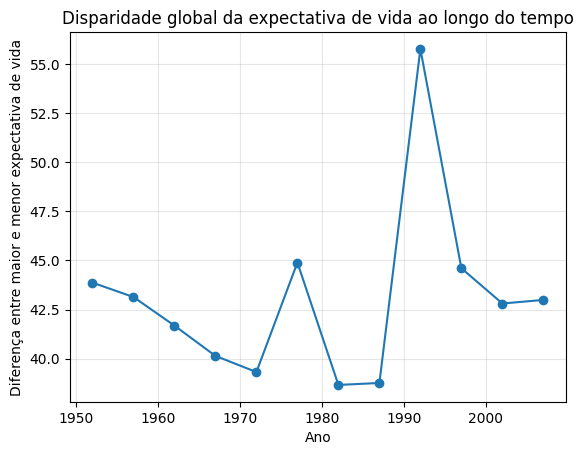

In [34]:
grafico_linha(
    data_frame=disparidade_ano,
    coluna_x="year",
    coluna_y="amplitude",
    titulo="Disparidade global da expectativa de vida ao longo do tempo",
    xlabel="Ano",
    ylabel="Diferença entre maior e menor expectativa de vida",
)


### Heterogeneidade da Ásia

#### Distribuição interna da Ásia em 2007

In [35]:
df_asia_2007 = df[(df["continent"] == 'Asia') & (df["year"] == 2007) ].sort_values("lifeExp", ascending=False)
df_asia_2007[["country", "lifeExp", "gdpPercap", "pop"]].head(10)

,country,lifeExp,gdpPercap,pop
835,Japan,82.603,31656.068060,127467972.0
703,Hong Kong China,82.208,39724.978670,6980412.0
799,Israel,80.745,25523.277100,6426679.0
1399,Singapore,79.972,47143.179640,4553009.0
883,Korea Rep.,78.623,23348.139730,49044790.0
1543,Taiwan,78.400,28718.276840,23174294.0
895,Kuwait,77.588,47306.989780,2505559.0
1195,Oman,75.640,22316.192870,3204897.0
96,Bahrain,75.635,29796.048340,708573.0
1687,Vietnam,74.249,2441.576404,85262356.0


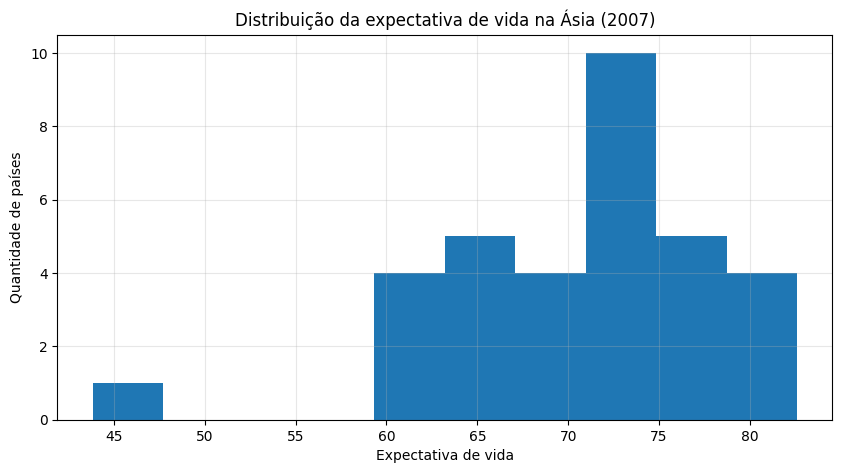

In [36]:
plt.figure(figsize=(10,5))
plt.hist(df_asia_2007['lifeExp'], bins=10)
plt.title("Distribuição da expectativa de vida na Ásia (2007)")
plt.xlabel("Expectativa de vida")
plt.ylabel("Quantidade de países")

plt.grid(True, alpha=0.3)
plt.show()

#### Trajetórias Asiáticas Selecionadas

In [37]:
df_asia = df[(df["continent"] == 'Asia')].sort_values("lifeExp", ascending=False)
df_asia

,country,year,pop,continent,lifeExp,gdpPercap
835,Japan,2007,127467972.0,Asia,82.603,31656.068060
703,Hong Kong China,2007,6980412.0,Asia,82.208,39724.978670
834,Japan,2002,127065841.0,Asia,82.000,28604.591900
702,Hong Kong China,2002,6762476.0,Asia,81.495,30209.015160
799,Israel,2007,6426679.0,Asia,80.745,25523.277100
...,...,...,...,...,...,...
1700,Yemen Rep.,1952,4963829.0,Asia,32.548,781.717576
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
229,Cambodia,1977,6978607.0,Asia,31.220,524.972183
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030


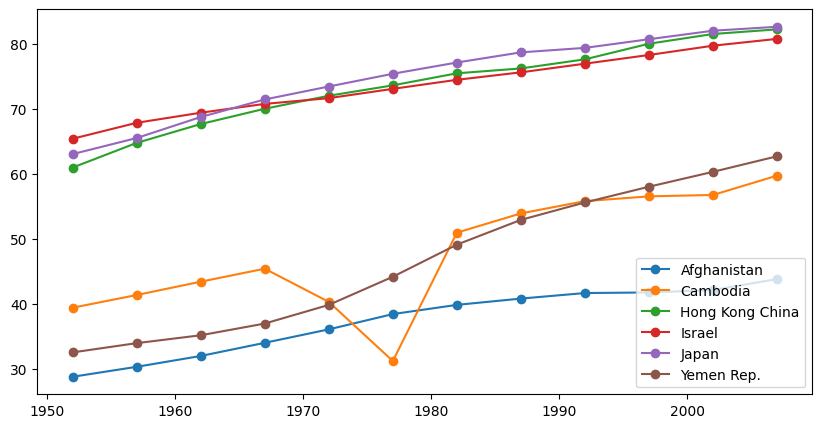

In [38]:
graf_evolu_pais(
    paises_por_ano=df_asia.sort_values(by=['country','year']).groupby('country'),
    paises=["Japan","Hong Kong China","Israel","Afghanistan","Cambodia","Yemen Rep."]
)

A análise da Ásia em 2007 foi priorizada por representar o ano mais recente do dataset e por evidenciar a heterogeneidade interna do continente. Embora a média continental asiática não esteja entre as mais altas, alguns países asiáticos aparecem entre os líderes globais em expectativa de vida.

## PIB e Desenvolvimento Humano

#### PIB vs Expectativa de Vida

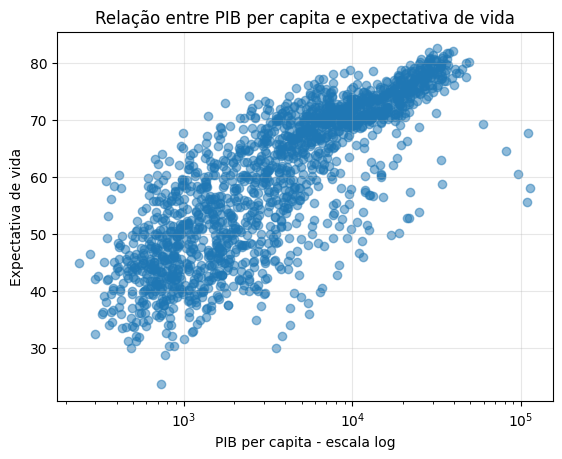

In [39]:
grafico_scatter(
    data_frame=df,
    coluna_x="gdpPercap",
    coluna_y="lifeExp",
    titulo="Relação entre PIB per capita e expectativa de vida",
    xlabel="PIB per capita - escala log",
    ylabel="Expectativa de vida",
    scale_x=Scale.LOG.value,
    alpha=0.5,
)


#### Correlações

<Axes: >

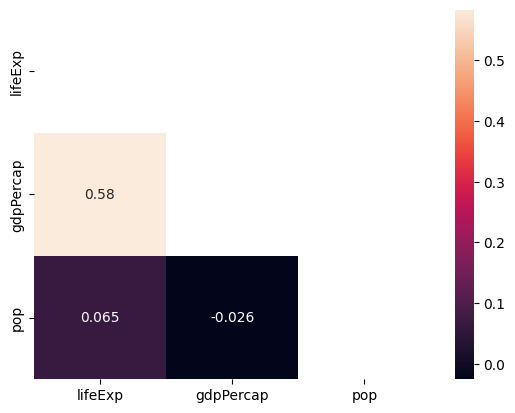

In [40]:


mask = np.triu(np.ones_like(df[["lifeExp", "gdpPercap", "pop"]].corr().round(2),dtype=bool))
sns.heatmap(data=df[["lifeExp", "gdpPercap", "pop"]].corr(), annot=True, mask=mask)

#### Países ricos com baixa expectativa

In [41]:
df_2007 = filtrar_ano(df, 2007)
limiar_pib_alto = df_2007["gdpPercap"].quantile(0.75)
limiar_pib_alto


np.float64(18008.835639999998)

In [42]:
paises_ricos = df_2007[df_2007["gdpPercap"] >= limiar_pib_alto]
paises_ricos

,country,year,pop,continent,lifeExp,gdpPercap
71,Australia,2007,20434176.0,Oceania,81.235,34435.36744
84,Austria,2007,8199783.0,Europe,79.829,36126.49270
96,Bahrain,2007,708573.0,Asia,75.635,29796.04834
120,Belgium,2007,10392226.0,Europe,79.441,33692.60508
260,Canada,2007,33390141.0,Americas,80.653,36319.23501
419,Czech Republic,2007,10228744.0,Europe,76.486,22833.30851
431,Denmark,2007,5468120.0,Europe,78.332,35278.41874
547,Finland,2007,5238460.0,Europe,79.313,33207.08440
559,France,2007,61083916.0,Europe,80.657,30470.01670
602,Germany,2007,82400996.0,Europe,79.406,32170.37442


In [43]:
ricos_baixa_life = top_n(
    paises_ricos,
    coluna="lifeExp",
    n=10,
    ascending=True,
    colunas=["country", "continent", "lifeExp", "gdpPercap", "pop"],
)
ricos_baixa_life


,country,continent,lifeExp,gdpPercap,pop
1351,Saudi Arabia,Asia,72.777,21654.83194,27601038.0
715,Hungary,Europe,73.338,18008.94444,9956108.0
1411,Slovak Republic,Europe,74.663,18678.31435,5447502.0
96,Bahrain,Asia,75.635,29796.04834,708573.0
1195,Oman,Asia,75.640,22316.19287,3204897.0
419,Czech Republic,Europe,76.486,22833.30851,10228744.0
895,Kuwait,Asia,77.588,47306.98978,2505559.0
1423,Slovenia,Europe,77.926,25768.25759,2009245.0
1279,Portugal,Europe,78.098,20509.64777,10642836.0
1651,United States,Americas,78.242,42951.65309,301139947.0


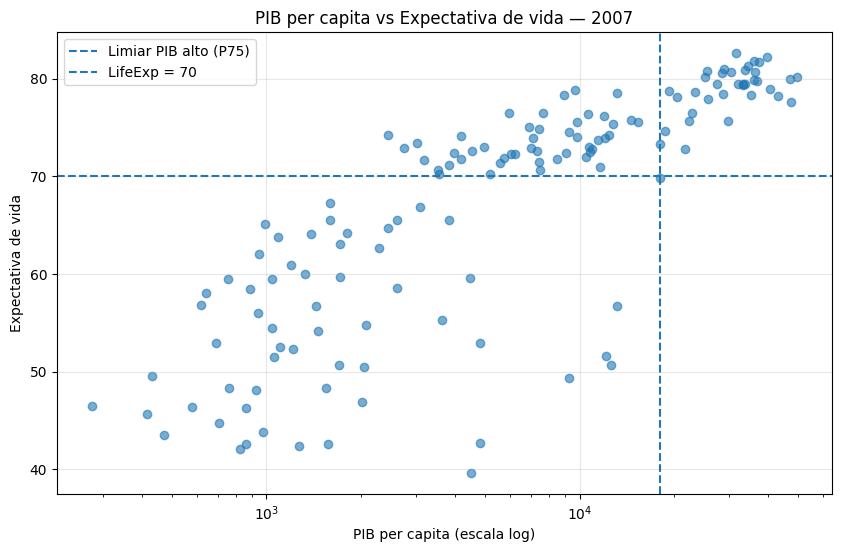

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_2007["gdpPercap"],
    df_2007["lifeExp"],
    alpha=0.6,
)

plt.axvline(
    limiar_pib_alto,
    linestyle="--",
    label="Limiar PIB alto (P75)",
)

plt.axhline(
    70,
    linestyle="--",
    label="LifeExp = 70",
)

plt.xscale(Scale.LOG.value)
aplicar_formatacao_grafico(
    titulo="PIB per capita vs Expectativa de vida — 2007",
    xlabel="PIB per capita (escala log)",
    ylabel="Expectativa de vida",
    legend=True,
)


#### PIB per capita e expectativa de vida em 2007

O gráfico mostra uma associação positiva entre PIB per capita e expectativa de vida em 2007. Países com menor PIB per capita concentram-se majoritariamente em faixas mais baixas de expectativa de vida, enquanto países com maior PIB per capita aparecem, em geral, acima de 70 anos.

A linha vertical representa o grupo de países com PIB per capita mais elevado, acima do percentil 75. Observa-se que praticamente todos os países desse grupo apresentam expectativa de vida superior a 70 anos. Isso indica que, dentro do dataset analisado, países com maior renda per capita tendem a apresentar melhores indicadores de longevidade.

Por outro lado, o gráfico também mostra que o aumento do PIB não produz ganhos lineares indefinidos em expectativa de vida. Entre países de renda mais baixa e intermediária, pequenos aumentos no PIB parecem estar associados a grandes diferenças na expectativa de vida. Já entre países de renda mais alta, os pontos se concentram em uma faixa mais estreita, geralmente entre 75 e 82 anos, sugerindo um possível efeito de saturação.

Também é possível observar alguns países com expectativa de vida relativamente baixa mesmo em faixas intermediárias de PIB per capita. Esses casos indicam que o PIB, embora relevante, não explica sozinho a qualidade de vida. Outros fatores, como acesso à saúde, saneamento, estabilidade política, desigualdade interna e mortalidade infantil, podem influenciar fortemente a expectativa de vida.

In [45]:
df_2007 = filtrar_ano(df, 2007)
df_2007["log_gdpPercap"] = np.log10(df_2007["gdpPercap"])

coef = np.polyfit(
    df_2007["log_gdpPercap"],
    df_2007["lifeExp"],
    deg=1,
)

df_2007["lifeExp_esperada"] = (
    coef[0] * df_2007["log_gdpPercap"] + coef[1]
)

df_2007["residuo_lifeExp"] = (
    df_2007["lifeExp"] - df_2007["lifeExp_esperada"]
)

paises_abaixo_esperado = top_n(
    df_2007[df_2007["gdpPercap"] >= df_2007["gdpPercap"].quantile(0.75)],
    coluna="residuo_lifeExp",
    n=10,
    ascending=True,
)

paises_abaixo_esperado[
    ["country", "continent", "lifeExp", "gdpPercap", "lifeExp_esperada", "residuo_lifeExp"]
]


,country,continent,lifeExp,gdpPercap,lifeExp_esperada,residuo_lifeExp
895,Kuwait,Asia,77.588,47306.98978,82.483545,-4.895545
1351,Saudi Arabia,Asia,72.777,21654.83194,76.855064,-4.078064
1651,United States,Americas,78.242,42951.65309,81.787877,-3.545877
96,Bahrain,Asia,75.635,29796.04834,79.153817,-3.518817
1183,Norway,Europe,80.196,49357.19017,82.789127,-2.593127
787,Ireland,Europe,78.885,40675.99635,81.395779,-2.510779
1399,Singapore,Asia,79.972,47143.17964,82.458561,-2.486561
715,Hungary,Europe,73.338,18008.94444,75.527155,-2.189155
431,Denmark,Europe,78.332,35278.41874,80.370339,-2.038339
1195,Oman,Asia,75.640,22316.19287,77.071752,-1.431752


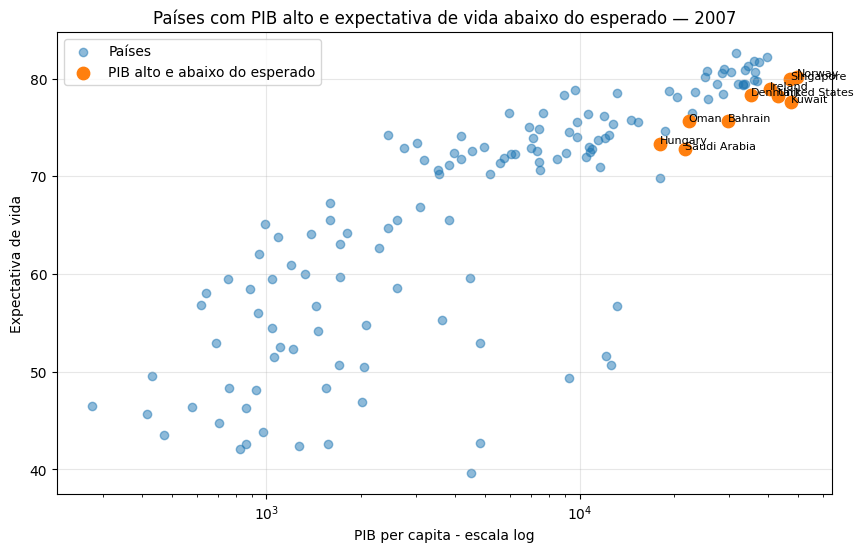

In [46]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_2007["gdpPercap"],
    df_2007["lifeExp"],
    alpha=0.5,
    label="Países",
)

plt.scatter(
    paises_abaixo_esperado["gdpPercap"],
    paises_abaixo_esperado["lifeExp"],
    s=80,
    label="PIB alto e abaixo do esperado",
)

anotar_paises(
    data_frame=paises_abaixo_esperado,
    coluna_x="gdpPercap",
    coluna_y="lifeExp",
)

plt.xscale(Scale.LOG.value)
aplicar_formatacao_grafico(
    titulo="Países com PIB alto e expectativa de vida abaixo do esperado — 2007",
    xlabel="PIB per capita - escala log",
    ylabel="Expectativa de vida",
    legend=True,
)


#### População vs Qualidade de Vida

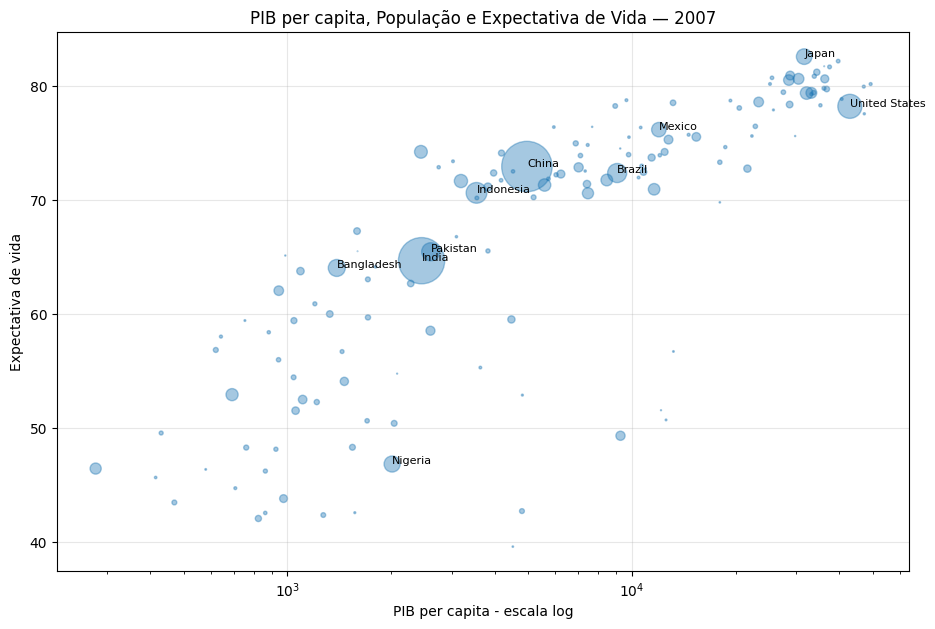

In [47]:
top_pop = top_n(df_2007, coluna="pop", n=10)

plt.figure(figsize=(11, 7))

plt.scatter(
    df_2007["gdpPercap"],
    df_2007["lifeExp"],
    s=df_2007["pop"] / 1_000_000,
    alpha=0.4,
)

anotar_paises(
    data_frame=top_pop,
    coluna_x="gdpPercap",
    coluna_y="lifeExp",
)

plt.xscale(Scale.LOG.value)
aplicar_formatacao_grafico(
    titulo="PIB per capita, População e Expectativa de Vida — 2007",
    xlabel="PIB per capita - escala log",
    ylabel="Expectativa de vida",
)


In [48]:
top_pop[
    ["country", "continent", "pop", "lifeExp", "gdpPercap"]
]

,country,continent,pop,lifeExp,gdpPercap
308,China,Asia,1.318683e+09,72.961,4959.114854
739,India,Asia,1.110396e+09,64.698,2452.210407
1651,United States,Americas,3.011399e+08,78.242,42951.653090
751,Indonesia,Asia,2.235470e+08,70.650,3540.651564
186,Brazil,Americas,1.900106e+08,72.390,9065.800825
1207,Pakistan,Asia,1.692706e+08,65.483,2605.947580
108,Bangladesh,Asia,1.504483e+08,64.062,1391.253792
1171,Nigeria,Africa,1.350312e+08,46.859,2013.977305
835,Japan,Asia,1.274680e+08,82.603,31656.068060
1027,Mexico,Americas,1.087009e+08,76.195,11977.574960


##### População vs Qualidade de Vida

Nesta análise, investigou-se se países mais populosos apresentam maior ou menor expectativa de vida. Para isso, foi utilizado o ano de 2007, por ser o período mais recente disponível no dataset.

A população foi representada em escala logarítmica, pois há grande diferença entre países pouco populosos e países extremamente populosos, como China e Índia. Essa transformação melhora a visualização e evita que países com populações muito grandes comprimam os demais pontos no gráfico.

A análise indica que a população total, isoladamente, não apresenta relação clara com a expectativa de vida. Países muito populosos aparecem em diferentes faixas de expectativa de vida, sugerindo que o tamanho populacional não é suficiente para explicar a qualidade de vida. Por outro lado, quando comparada ao PIB per capita, a expectativa de vida apresenta uma relação mais evidente com o nível de desenvolvimento econômico.

## Síntese dos Principais Insights

A análise exploratória indica que a expectativa de vida aumentou de forma consistente entre 1952 e 2007. No entanto, esse avanço não ocorreu de maneira homogênea entre continentes e países.

Os principais achados foram:

- houve crescimento global da expectativa de vida ao longo do período;
- Europa e Oceania apresentaram os maiores níveis médios de expectativa de vida;
- a África melhorou ao longo do tempo, mas permaneceu abaixo dos demais continentes;
- a Ásia apresentou forte heterogeneidade interna, com países entre os líderes globais e outros ainda em patamares inferiores;
- o PIB per capita apresentou relação positiva com expectativa de vida, especialmente quando analisado em escala logarítmica;
- a população total, isoladamente, não demonstrou relação direta forte com expectativa de vida;
- alguns países apresentam expectativa de vida abaixo do esperado mesmo com PIB per capita relativamente alto, indicando que renda não explica sozinha o desenvolvimento humano.


## Limitações da Análise

Apesar dos padrões identificados, algumas limitações precisam ser consideradas:

- o dataset Gapminder possui observações em intervalos de 5 anos, não permitindo análise anual detalhada;
- a média global simples dá o mesmo peso a países com populações muito diferentes;
- algumas análises por continente podem esconder grande heterogeneidade interna;
- a Oceania possui poucos países no dataset, o que torna sua média menos comparável à de continentes mais numerosos;
- correlações não indicam causalidade;
- variáveis externas enriquecidas foram avaliadas, mas algumas apresentaram baixa cobertura temporal e geográfica, limitando sua utilização como evidência central.


## Conclusão

O trabalho demonstrou como a Análise Exploratória de Dados pode revelar padrões importantes sobre desenvolvimento humano global. A expectativa de vida aumentou substancialmente entre 1952 e 2007, mas desigualdades persistiram entre continentes e países.

A análise também mostrou que o PIB per capita está associado a melhores níveis de expectativa de vida, mas não explica sozinho a qualidade de vida.

Como aprendizado, a análise reforça a importância de validar a qualidade dos dados, escolher visualizações adequadas para cada pergunta e interpretar resultados com cautela metodológica.
